# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
path_catboost = os.path.join(MODEL, "CatBoost_Fine_Tune")
path_xgboost = os.path.join(MODEL, "XGBoost_Fine_Tune")
path_lightgbm = os.path.join(MODEL, "LightGBM_Fine_Tune")

model_params_dict = {
    "Catboost": os.path.join(path_catboost, "best_params.yaml"),
    "XGBoost": os.path.join(path_xgboost, "best_params.yaml"),
    "LightGBM": os.path.join(path_lightgbm, "best_params.yaml"),
}

model_params_dict

{'Catboost': '/home/gpaek/SED-Classifier/notebook/../model/CatBoost_Fine_Tune/best_params.yaml',
 'XGBoost': '/home/gpaek/SED-Classifier/notebook/../model/XGBoost_Fine_Tune/best_params.yaml',
 'LightGBM': '/home/gpaek/SED-Classifier/notebook/../model/LightGBM_Fine_Tune/best_params.yaml'}

In [10]:
# Set experiment configs
test_name = "Compare_Top3"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"

- Source to Consider

In [11]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [12]:
# path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')
path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40_only_color.csv')

logtxt += f"\nBalanced Data Set\n"

In [13]:
path_save = os.path.join(MODEL, "three_top_models")
os.makedirs(path_save, exist_ok=True)

# Data

In [14]:
data_dtype_dict = {
	'Sample_ID': int,
	'Class': str,
	'uid': str,
	'm400-m412': float,
	'm400-m425': float,
	'm400-m437': float,
	'm400-m450': float,
	'm400-m462': float,
	'm400-m475': float,
	'm400-m487': float,
	'm400-m500': float,
	'm400-m512': float,
	'm400-m525': float,
	'm400-m537': float,
	'm400-m550': float,
	'm400-m562': float,
	'm400-m575': float,
	'm400-m587': float,
	'm400-m600': float,
	'm400-m612': float,
	'm400-m625': float,
	'm400-m637': float,
	'm400-m650': float,
	'm400-m662': float,
	'm400-m675': float,
	'm400-m687': float,
	'm400-m700': float,
	'm400-m712': float,
	'm400-m725': float,
	'm400-m737': float,
	'm400-m750': float,
	'm400-m762': float,
	'm400-m775': float,
	'm400-m787': float,
	'm400-m800': float,
	'm400-m812': float,
	'm400-m825': float,
	'm400-m837': float,
	'm400-m850': float,
	'm400-m862': float,
	'm400-m875': float,
	'm400-m887': float,
	'm412-m425': float,
	'm412-m437': float,
	'm412-m450': float,
	'm412-m462': float,
	'm412-m475': float,
	'm412-m487': float,
	'm412-m500': float,
	'm412-m512': float,
	'm412-m525': float,
	'm412-m537': float,
	'm412-m550': float,
	'm412-m562': float,
	'm412-m575': float,
	'm412-m587': float,
	'm412-m600': float,
	'm412-m612': float,
	'm412-m625': float,
	'm412-m637': float,
	'm412-m650': float,
	'm412-m662': float,
	'm412-m675': float,
	'm412-m687': float,
	'm412-m700': float,
	'm412-m712': float,
	'm412-m725': float,
	'm412-m737': float,
	'm412-m750': float,
	'm412-m762': float,
	'm412-m775': float,
	'm412-m787': float,
	'm412-m800': float,
	'm412-m812': float,
	'm412-m825': float,
	'm412-m837': float,
	'm412-m850': float,
	'm412-m862': float,
	'm412-m875': float,
	'm412-m887': float,
	'm425-m437': float,
	'm425-m450': float,
	'm425-m462': float,
	'm425-m475': float,
	'm425-m487': float,
	'm425-m500': float,
	'm425-m512': float,
	'm425-m525': float,
	'm425-m537': float,
	'm425-m550': float,
	'm425-m562': float,
	'm425-m575': float,
	'm425-m587': float,
	'm425-m600': float,
	'm425-m612': float,
	'm425-m625': float,
	'm425-m637': float,
	'm425-m650': float,
	'm425-m662': float,
	'm425-m675': float,
	'm425-m687': float,
	'm425-m700': float,
	'm425-m712': float,
	'm425-m725': float,
	'm425-m737': float,
	'm425-m750': float,
	'm425-m762': float,
	'm425-m775': float,
	'm425-m787': float,
	'm425-m800': float,
	'm425-m812': float,
	'm425-m825': float,
	'm425-m837': float,
	'm425-m850': float,
	'm425-m862': float,
	'm425-m875': float,
	'm425-m887': float,
	'm437-m450': float,
	'm437-m462': float,
	'm437-m475': float,
	'm437-m487': float,
	'm437-m500': float,
	'm437-m512': float,
	'm437-m525': float,
	'm437-m537': float,
	'm437-m550': float,
	'm437-m562': float,
	'm437-m575': float,
	'm437-m587': float,
	'm437-m600': float,
	'm437-m612': float,
	'm437-m625': float,
	'm437-m637': float,
	'm437-m650': float,
	'm437-m662': float,
	'm437-m675': float,
	'm437-m687': float,
	'm437-m700': float,
	'm437-m712': float,
	'm437-m725': float,
	'm437-m737': float,
	'm437-m750': float,
	'm437-m762': float,
	'm437-m775': float,
	'm437-m787': float,
	'm437-m800': float,
	'm437-m812': float,
	'm437-m825': float,
	'm437-m837': float,
	'm437-m850': float,
	'm437-m862': float,
	'm437-m875': float,
	'm437-m887': float,
	'm450-m462': float,
	'm450-m475': float,
	'm450-m487': float,
	'm450-m500': float,
	'm450-m512': float,
	'm450-m525': float,
	'm450-m537': float,
	'm450-m550': float,
	'm450-m562': float,
	'm450-m575': float,
	'm450-m587': float,
	'm450-m600': float,
	'm450-m612': float,
	'm450-m625': float,
	'm450-m637': float,
	'm450-m650': float,
	'm450-m662': float,
	'm450-m675': float,
	'm450-m687': float,
	'm450-m700': float,
	'm450-m712': float,
	'm450-m725': float,
	'm450-m737': float,
	'm450-m750': float,
	'm450-m762': float,
	'm450-m775': float,
	'm450-m787': float,
	'm450-m800': float,
	'm450-m812': float,
	'm450-m825': float,
	'm450-m837': float,
	'm450-m850': float,
	'm450-m862': float,
	'm450-m875': float,
	'm450-m887': float,
	'm462-m475': float,
	'm462-m487': float,
	'm462-m500': float,
	'm462-m512': float,
	'm462-m525': float,
	'm462-m537': float,
	'm462-m550': float,
	'm462-m562': float,
	'm462-m575': float,
	'm462-m587': float,
	'm462-m600': float,
	'm462-m612': float,
	'm462-m625': float,
	'm462-m637': float,
	'm462-m650': float,
	'm462-m662': float,
	'm462-m675': float,
	'm462-m687': float,
	'm462-m700': float,
	'm462-m712': float,
	'm462-m725': float,
	'm462-m737': float,
	'm462-m750': float,
	'm462-m762': float,
	'm462-m775': float,
	'm462-m787': float,
	'm462-m800': float,
	'm462-m812': float,
	'm462-m825': float,
	'm462-m837': float,
	'm462-m850': float,
	'm462-m862': float,
	'm462-m875': float,
	'm462-m887': float,
	'm475-m487': float,
	'm475-m500': float,
	'm475-m512': float,
	'm475-m525': float,
	'm475-m537': float,
	'm475-m550': float,
	'm475-m562': float,
	'm475-m575': float,
	'm475-m587': float,
	'm475-m600': float,
	'm475-m612': float,
	'm475-m625': float,
	'm475-m637': float,
	'm475-m650': float,
	'm475-m662': float,
	'm475-m675': float,
	'm475-m687': float,
	'm475-m700': float,
	'm475-m712': float,
	'm475-m725': float,
	'm475-m737': float,
	'm475-m750': float,
	'm475-m762': float,
	'm475-m775': float,
	'm475-m787': float,
	'm475-m800': float,
	'm475-m812': float,
	'm475-m825': float,
	'm475-m837': float,
	'm475-m850': float,
	'm475-m862': float,
	'm475-m875': float,
	'm475-m887': float,
	'm487-m500': float,
	'm487-m512': float,
	'm487-m525': float,
	'm487-m537': float,
	'm487-m550': float,
	'm487-m562': float,
	'm487-m575': float,
	'm487-m587': float,
	'm487-m600': float,
	'm487-m612': float,
	'm487-m625': float,
	'm487-m637': float,
	'm487-m650': float,
	'm487-m662': float,
	'm487-m675': float,
	'm487-m687': float,
	'm487-m700': float,
	'm487-m712': float,
	'm487-m725': float,
	'm487-m737': float,
	'm487-m750': float,
	'm487-m762': float,
	'm487-m775': float,
	'm487-m787': float,
	'm487-m800': float,
	'm487-m812': float,
	'm487-m825': float,
	'm487-m837': float,
	'm487-m850': float,
	'm487-m862': float,
	'm487-m875': float,
	'm487-m887': float,
	'm500-m512': float,
	'm500-m525': float,
	'm500-m537': float,
	'm500-m550': float,
	'm500-m562': float,
	'm500-m575': float,
	'm500-m587': float,
	'm500-m600': float,
	'm500-m612': float,
	'm500-m625': float,
	'm500-m637': float,
	'm500-m650': float,
	'm500-m662': float,
	'm500-m675': float,
	'm500-m687': float,
	'm500-m700': float,
	'm500-m712': float,
	'm500-m725': float,
	'm500-m737': float,
	'm500-m750': float,
	'm500-m762': float,
	'm500-m775': float,
	'm500-m787': float,
	'm500-m800': float,
	'm500-m812': float,
	'm500-m825': float,
	'm500-m837': float,
	'm500-m850': float,
	'm500-m862': float,
	'm500-m875': float,
	'm500-m887': float,
	'm512-m525': float,
	'm512-m537': float,
	'm512-m550': float,
	'm512-m562': float,
	'm512-m575': float,
	'm512-m587': float,
	'm512-m600': float,
	'm512-m612': float,
	'm512-m625': float,
	'm512-m637': float,
	'm512-m650': float,
	'm512-m662': float,
	'm512-m675': float,
	'm512-m687': float,
	'm512-m700': float,
	'm512-m712': float,
	'm512-m725': float,
	'm512-m737': float,
	'm512-m750': float,
	'm512-m762': float,
	'm512-m775': float,
	'm512-m787': float,
	'm512-m800': float,
	'm512-m812': float,
	'm512-m825': float,
	'm512-m837': float,
	'm512-m850': float,
	'm512-m862': float,
	'm512-m875': float,
	'm512-m887': float,
	'm525-m537': float,
	'm525-m550': float,
	'm525-m562': float,
	'm525-m575': float,
	'm525-m587': float,
	'm525-m600': float,
	'm525-m612': float,
	'm525-m625': float,
	'm525-m637': float,
	'm525-m650': float,
	'm525-m662': float,
	'm525-m675': float,
	'm525-m687': float,
	'm525-m700': float,
	'm525-m712': float,
	'm525-m725': float,
	'm525-m737': float,
	'm525-m750': float,
	'm525-m762': float,
	'm525-m775': float,
	'm525-m787': float,
	'm525-m800': float,
	'm525-m812': float,
	'm525-m825': float,
	'm525-m837': float,
	'm525-m850': float,
	'm525-m862': float,
	'm525-m875': float,
	'm525-m887': float,
	'm537-m550': float,
	'm537-m562': float,
	'm537-m575': float,
	'm537-m587': float,
	'm537-m600': float,
	'm537-m612': float,
	'm537-m625': float,
	'm537-m637': float,
	'm537-m650': float,
	'm537-m662': float,
	'm537-m675': float,
	'm537-m687': float,
	'm537-m700': float,
	'm537-m712': float,
	'm537-m725': float,
	'm537-m737': float,
	'm537-m750': float,
	'm537-m762': float,
	'm537-m775': float,
	'm537-m787': float,
	'm537-m800': float,
	'm537-m812': float,
	'm537-m825': float,
	'm537-m837': float,
	'm537-m850': float,
	'm537-m862': float,
	'm537-m875': float,
	'm537-m887': float,
	'm550-m562': float,
	'm550-m575': float,
	'm550-m587': float,
	'm550-m600': float,
	'm550-m612': float,
	'm550-m625': float,
	'm550-m637': float,
	'm550-m650': float,
	'm550-m662': float,
	'm550-m675': float,
	'm550-m687': float,
	'm550-m700': float,
	'm550-m712': float,
	'm550-m725': float,
	'm550-m737': float,
	'm550-m750': float,
	'm550-m762': float,
	'm550-m775': float,
	'm550-m787': float,
	'm550-m800': float,
	'm550-m812': float,
	'm550-m825': float,
	'm550-m837': float,
	'm550-m850': float,
	'm550-m862': float,
	'm550-m875': float,
	'm550-m887': float,
	'm562-m575': float,
	'm562-m587': float,
	'm562-m600': float,
	'm562-m612': float,
	'm562-m625': float,
	'm562-m637': float,
	'm562-m650': float,
	'm562-m662': float,
	'm562-m675': float,
	'm562-m687': float,
	'm562-m700': float,
	'm562-m712': float,
	'm562-m725': float,
	'm562-m737': float,
	'm562-m750': float,
	'm562-m762': float,
	'm562-m775': float,
	'm562-m787': float,
	'm562-m800': float,
	'm562-m812': float,
	'm562-m825': float,
	'm562-m837': float,
	'm562-m850': float,
	'm562-m862': float,
	'm562-m875': float,
	'm562-m887': float,
	'm575-m587': float,
	'm575-m600': float,
	'm575-m612': float,
	'm575-m625': float,
	'm575-m637': float,
	'm575-m650': float,
	'm575-m662': float,
	'm575-m675': float,
	'm575-m687': float,
	'm575-m700': float,
	'm575-m712': float,
	'm575-m725': float,
	'm575-m737': float,
	'm575-m750': float,
	'm575-m762': float,
	'm575-m775': float,
	'm575-m787': float,
	'm575-m800': float,
	'm575-m812': float,
	'm575-m825': float,
	'm575-m837': float,
	'm575-m850': float,
	'm575-m862': float,
	'm575-m875': float,
	'm575-m887': float,
	'm587-m600': float,
	'm587-m612': float,
	'm587-m625': float,
	'm587-m637': float,
	'm587-m650': float,
	'm587-m662': float,
	'm587-m675': float,
	'm587-m687': float,
	'm587-m700': float,
	'm587-m712': float,
	'm587-m725': float,
	'm587-m737': float,
	'm587-m750': float,
	'm587-m762': float,
	'm587-m775': float,
	'm587-m787': float,
	'm587-m800': float,
	'm587-m812': float,
	'm587-m825': float,
	'm587-m837': float,
	'm587-m850': float,
	'm587-m862': float,
	'm587-m875': float,
	'm587-m887': float,
	'm600-m612': float,
	'm600-m625': float,
	'm600-m637': float,
	'm600-m650': float,
	'm600-m662': float,
	'm600-m675': float,
	'm600-m687': float,
	'm600-m700': float,
	'm600-m712': float,
	'm600-m725': float,
	'm600-m737': float,
	'm600-m750': float,
	'm600-m762': float,
	'm600-m775': float,
	'm600-m787': float,
	'm600-m800': float,
	'm600-m812': float,
	'm600-m825': float,
	'm600-m837': float,
	'm600-m850': float,
	'm600-m862': float,
	'm600-m875': float,
	'm600-m887': float,
	'm612-m625': float,
	'm612-m637': float,
	'm612-m650': float,
	'm612-m662': float,
	'm612-m675': float,
	'm612-m687': float,
	'm612-m700': float,
	'm612-m712': float,
	'm612-m725': float,
	'm612-m737': float,
	'm612-m750': float,
	'm612-m762': float,
	'm612-m775': float,
	'm612-m787': float,
	'm612-m800': float,
	'm612-m812': float,
	'm612-m825': float,
	'm612-m837': float,
	'm612-m850': float,
	'm612-m862': float,
	'm612-m875': float,
	'm612-m887': float,
	'm625-m637': float,
	'm625-m650': float,
	'm625-m662': float,
	'm625-m675': float,
	'm625-m687': float,
	'm625-m700': float,
	'm625-m712': float,
	'm625-m725': float,
	'm625-m737': float,
	'm625-m750': float,
	'm625-m762': float,
	'm625-m775': float,
	'm625-m787': float,
	'm625-m800': float,
	'm625-m812': float,
	'm625-m825': float,
	'm625-m837': float,
	'm625-m850': float,
	'm625-m862': float,
	'm625-m875': float,
	'm625-m887': float,
	'm637-m650': float,
	'm637-m662': float,
	'm637-m675': float,
	'm637-m687': float,
	'm637-m700': float,
	'm637-m712': float,
	'm637-m725': float,
	'm637-m737': float,
	'm637-m750': float,
	'm637-m762': float,
	'm637-m775': float,
	'm637-m787': float,
	'm637-m800': float,
	'm637-m812': float,
	'm637-m825': float,
	'm637-m837': float,
	'm637-m850': float,
	'm637-m862': float,
	'm637-m875': float,
	'm637-m887': float,
	'm650-m662': float,
	'm650-m675': float,
	'm650-m687': float,
	'm650-m700': float,
	'm650-m712': float,
	'm650-m725': float,
	'm650-m737': float,
	'm650-m750': float,
	'm650-m762': float,
	'm650-m775': float,
	'm650-m787': float,
	'm650-m800': float,
	'm650-m812': float,
	'm650-m825': float,
	'm650-m837': float,
	'm650-m850': float,
	'm650-m862': float,
	'm650-m875': float,
	'm650-m887': float,
	'm662-m675': float,
	'm662-m687': float,
	'm662-m700': float,
	'm662-m712': float,
	'm662-m725': float,
	'm662-m737': float,
	'm662-m750': float,
	'm662-m762': float,
	'm662-m775': float,
	'm662-m787': float,
	'm662-m800': float,
	'm662-m812': float,
	'm662-m825': float,
	'm662-m837': float,
	'm662-m850': float,
	'm662-m862': float,
	'm662-m875': float,
	'm662-m887': float,
	'm675-m687': float,
	'm675-m700': float,
	'm675-m712': float,
	'm675-m725': float,
	'm675-m737': float,
	'm675-m750': float,
	'm675-m762': float,
	'm675-m775': float,
	'm675-m787': float,
	'm675-m800': float,
	'm675-m812': float,
	'm675-m825': float,
	'm675-m837': float,
	'm675-m850': float,
	'm675-m862': float,
	'm675-m875': float,
	'm675-m887': float,
	'm687-m700': float,
	'm687-m712': float,
	'm687-m725': float,
	'm687-m737': float,
	'm687-m750': float,
	'm687-m762': float,
	'm687-m775': float,
	'm687-m787': float,
	'm687-m800': float,
	'm687-m812': float,
	'm687-m825': float,
	'm687-m837': float,
	'm687-m850': float,
	'm687-m862': float,
	'm687-m875': float,
	'm687-m887': float,
	'm700-m712': float,
	'm700-m725': float,
	'm700-m737': float,
	'm700-m750': float,
	'm700-m762': float,
	'm700-m775': float,
	'm700-m787': float,
	'm700-m800': float,
	'm700-m812': float,
	'm700-m825': float,
	'm700-m837': float,
	'm700-m850': float,
	'm700-m862': float,
	'm700-m875': float,
	'm700-m887': float,
	'm712-m725': float,
	'm712-m737': float,
	'm712-m750': float,
	'm712-m762': float,
	'm712-m775': float,
	'm712-m787': float,
	'm712-m800': float,
	'm712-m812': float,
	'm712-m825': float,
	'm712-m837': float,
	'm712-m850': float,
	'm712-m862': float,
	'm712-m875': float,
	'm712-m887': float,
	'm725-m737': float,
	'm725-m750': float,
	'm725-m762': float,
	'm725-m775': float,
	'm725-m787': float,
	'm725-m800': float,
	'm725-m812': float,
	'm725-m825': float,
	'm725-m837': float,
	'm725-m850': float,
	'm725-m862': float,
	'm725-m875': float,
	'm725-m887': float,
	'm737-m750': float,
	'm737-m762': float,
	'm737-m775': float,
	'm737-m787': float,
	'm737-m800': float,
	'm737-m812': float,
	'm737-m825': float,
	'm737-m837': float,
	'm737-m850': float,
	'm737-m862': float,
	'm737-m875': float,
	'm737-m887': float,
	'm750-m762': float,
	'm750-m775': float,
	'm750-m787': float,
	'm750-m800': float,
	'm750-m812': float,
	'm750-m825': float,
	'm750-m837': float,
	'm750-m850': float,
	'm750-m862': float,
	'm750-m875': float,
	'm750-m887': float,
	'm762-m775': float,
	'm762-m787': float,
	'm762-m800': float,
	'm762-m812': float,
	'm762-m825': float,
	'm762-m837': float,
	'm762-m850': float,
	'm762-m862': float,
	'm762-m875': float,
	'm762-m887': float,
	'm775-m787': float,
	'm775-m800': float,
	'm775-m812': float,
	'm775-m825': float,
	'm775-m837': float,
	'm775-m850': float,
	'm775-m862': float,
	'm775-m875': float,
	'm775-m887': float,
	'm787-m800': float,
	'm787-m812': float,
	'm787-m825': float,
	'm787-m837': float,
	'm787-m850': float,
	'm787-m862': float,
	'm787-m875': float,
	'm787-m887': float,
	'm800-m812': float,
	'm800-m825': float,
	'm800-m837': float,
	'm800-m850': float,
	'm800-m862': float,
	'm800-m875': float,
	'm800-m887': float,
	'm812-m825': float,
	'm812-m837': float,
	'm812-m850': float,
	'm812-m862': float,
	'm812-m875': float,
	'm812-m887': float,
	'm825-m837': float,
	'm825-m850': float,
	'm825-m862': float,
	'm825-m875': float,
	'm825-m887': float,
	'm837-m850': float,
	'm837-m862': float,
	'm837-m875': float,
	'm837-m887': float,
	'm850-m862': float,
	'm850-m875': float,
	'm850-m887': float,
	'm862-m875': float,
	'm862-m887': float,
	'm875-m887': float,
}


In [15]:
columns_to_use = list(data_dtype_dict.keys())

In [16]:
data = pd.read_csv(
    path_data,
    engine='c', 
    usecols=columns_to_use,
    dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 282753
10 sources to consider: 282753


- Training and Test Data

In [17]:
# - Split features/target
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
X.fillna(-99, inplace=True)
y = data['Class']
uids = data['uid']


# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

from catboost import CatBoostClassifier, Pool

# - Label encode class for ML
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)


Balanced: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'SLSN' 'TDE']


In [18]:
from catboost import CatBoostClassifier, Pool
# CatBoost
# cat_train_data = Pool(data=X_train, label=y_train_encoded)
# cat_test_data = Pool(data=X_test, label=y_test_encoded)

import lightgbm as lgb
# lgb_train_data = lgb.Dataset(X_train, label=y_train_encoded)
# lgb_test_data = lgb.Dataset(X_test, label=y_test_encoded, reference=train_data)

import xgboost as xgb
# xgb_train_data = xgb.DMatrix(X_train, label=y_train_encoded)
# xgb_test_data = xgb.DMatrix(X_test, label=y_test_encoded)

In [19]:
del data

# Model

In [20]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from xgboost.callback import EarlyStopping


from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [21]:
n_jobs = -1

CatBoost Training Start
{'border_count': 200, 'depth': 5, 'iterations': 1383, 'l2_leaf_reg': 3, 'learning_rate': 0.029567989986714113, 'random_state': 42, 'thread_count': -1}
CatBoost model exists. Loading model.


TBB Warning: The number of workers is currently limited to 19. The request for 23 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



XGBoost Training Start
{'colsample_bytree': 0.8267500788217794, 'gamma': 0.44209594451199286, 'learning_rate': 0.28864022968866265, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 1333, 'reg_lambda': 62.20766214503429, 'subsample': 0.9996711775883176, 'random_state': 42, 'nthread': -1}
XGBoost model exists. Loading model.
LightGBM Training Start
{'colsample_bytree': 0.8342131273421189, 'learning_rate': 0.09939493808165245, 'min_child_weight': 19, 'n_estimators': 71, 'num_leaves': 27, 'num_threads': -1, 'random_state': 42}
LightGBM model exists. Loading model.

=== Summary Table ===
                 CatBoost   XGBoost  LightGBM
accuracy         0.751314  0.765804  0.760767
macro_f1         0.752196  0.772247  0.773273
macro_precision   0.75941  0.787962  0.781369
macro_recall      0.75602  0.772272  0.779542


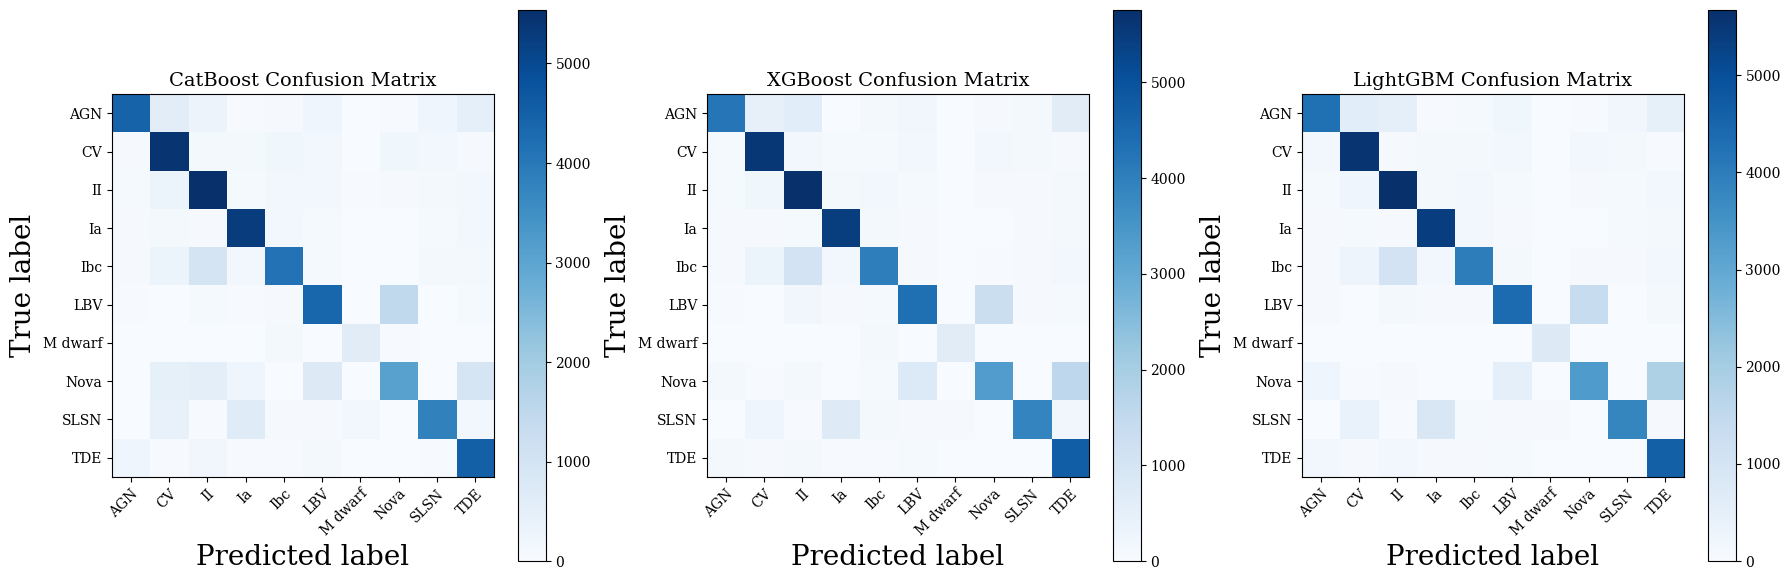

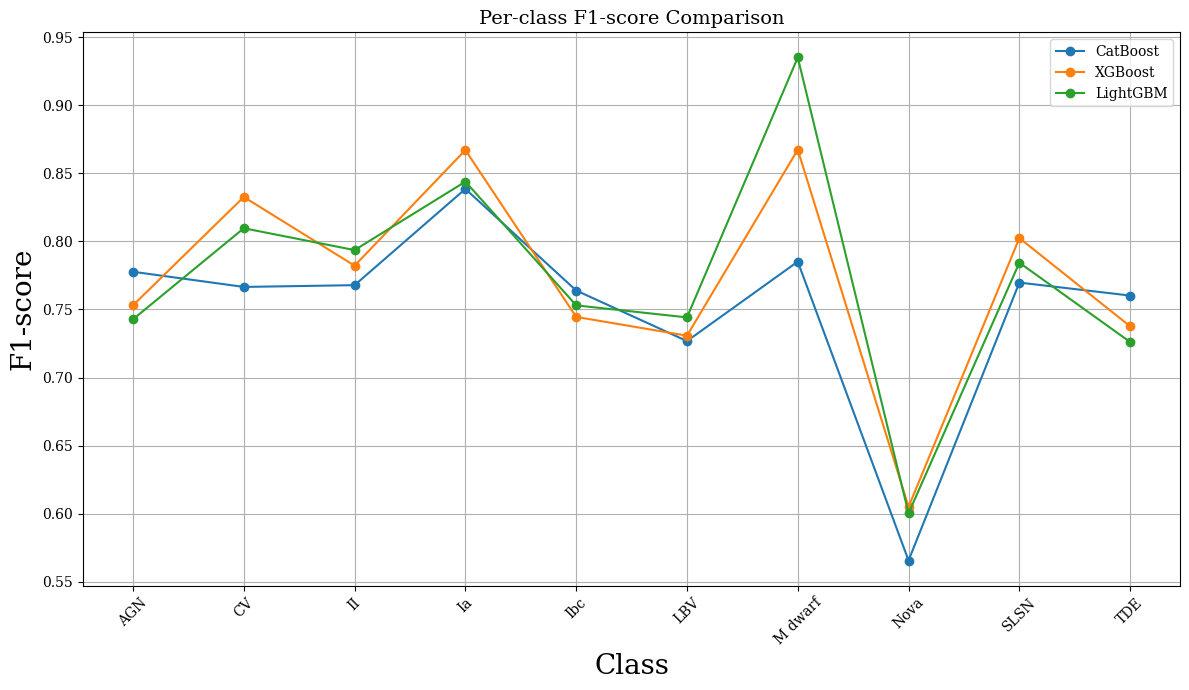

모든 실험 결과 및 비교 시각화가 저장되었습니다.


In [22]:
import yaml

# ---------------------------------------------------------
# 1. Load Best Hyperparameters from YAML
# ---------------------------------------------------------
def load_yaml_params(path_yaml):
    with open(path_yaml, "r") as f:
        params = yaml.safe_load(f)
    return params

cat_params = load_yaml_params(model_params_dict["Catboost"])
cat_params['thread_count'] = n_jobs
xgb_params = load_yaml_params(model_params_dict["XGBoost"])
xgb_params['nthread'] = n_jobs
lgbm_params = load_yaml_params(model_params_dict["LightGBM"])
lgbm_params['num_threads'] = n_jobs

logtxt += f"Loaded CatBoost params: {cat_params}\n"
logtxt += f"Loaded XGBoost params: {xgb_params}\n"
logtxt += f"Loaded LightGBM params: {lgbm_params}\n"

# ---------------------------------------------------------
# 2. Train & Evaluate Each Model
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

results_dict = {}

## 2-1. CatBoost
print("CatBoost Training Start")
print(cat_params)
# cat_model = CatBoostClassifier(**cat_params, verbose=0)
# cat_model.fit(X_train, y_train_encoded)
cat_model_path = os.path.join(path_save, "best_catboost_model.txt")
if os.path.exists(cat_model_path):
    print("CatBoost model exists. Loading model.")
    from catboost import CatBoostClassifier
    cat_model = CatBoostClassifier()
    cat_model.load_model(cat_model_path)
else:
    print("Training CatBoost model...")
    cat_model = CatBoostClassifier(**cat_params, verbose=0)
    cat_model.fit(X_train, y_train_encoded)
    cat_model.save_model(cat_model_path)

cat_pred = cat_model.predict(X_test)
cat_probs = cat_model.predict_proba(X_test)
results_dict['CatBoost'] = {
    'y_pred': cat_pred,
    'proba': cat_probs,
}

## 2-2. XGBoost
print("XGBoost Training Start")
print(xgb_params)
# xgb_model = XGBClassifier(**xgb_params, n_jobs=n_jobs, use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
# xgb_model.fit(X_train, y_train_encoded)
xgb_model_path = os.path.join(path_save, "best_xgboost_model.json")
if os.path.exists(xgb_model_path):
    print("XGBoost model exists. Loading model.")
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier()
    xgb_model.load_model(xgb_model_path)
else:
    print("Training XGBoost model...")
    xgb_model = XGBClassifier(**xgb_params, n_jobs=n_jobs, use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
    xgb_model.fit(X_train, y_train_encoded)
    xgb_model.save_model(xgb_model_path)
xgb_pred = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)
results_dict['XGBoost'] = {
    'y_pred': xgb_pred,
    'proba': xgb_probs,
}


## 2-3. LightGBM
print("LightGBM Training Start")
print(lgbm_params)
# lgbm_model = LGBMClassifier(**lgbm_params, n_jobs=n_jobs)
# lgbm_model.fit(X_train, y_train_encoded)
lgbm_model_path = os.path.join(path_save, "best_lightgbm_model.pkl")
if os.path.exists(lgbm_model_path):
    print("LightGBM model exists. Loading model.")
    import joblib
    lgbm_model = joblib.load(lgbm_model_path)
else:
    print("Training LightGBM model...")
    lgbm_model = LGBMClassifier(**lgbm_params, n_jobs=n_jobs)
    lgbm_model.fit(X_train, y_train_encoded)
    joblib.dump(lgbm_model, lgbm_model_path)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_probs = lgbm_model.predict_proba(X_test)
results_dict['LightGBM'] = {
    'y_pred': lgbm_pred,
    'proba': lgbm_probs,
}

# ---------------------------------------------------------
# 3. Calculate & Compare Metrics
# ---------------------------------------------------------
metrics_summary = pd.DataFrame(index=['accuracy', 'macro_f1', 'macro_precision', 'macro_recall'], columns=results_dict.keys())

for model_name, res in results_dict.items():
    acc = accuracy_score(y_test_encoded, res['y_pred'])
    macro_f1 = f1_score(y_test_encoded, res['y_pred'], average='macro')
    macro_prec = precision_score(y_test_encoded, res['y_pred'], average='macro')
    macro_recall = recall_score(y_test_encoded, res['y_pred'], average='macro')
    metrics_summary.loc[:, model_name] = [acc, macro_f1, macro_prec, macro_recall]
    logtxt += f"{model_name} results\n"
    logtxt += classification_report(y_test_encoded, res['y_pred'], target_names=class_names)
    logtxt += "\n"

print("\n=== Summary Table ===")
print(metrics_summary)
metrics_summary.to_csv(os.path.join(path_save, "metrics_summary.csv"))

# ---------------------------------------------------------
# 4. Per-class Metrics and Confusion Matrix
# ---------------------------------------------------------
def plot_confusion_matrix(cm, classes, title, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           ylabel='True label', xlabel='Predicted label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_title(title)
    plt.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, model_name in enumerate(results_dict.keys()):
    cm = confusion_matrix(y_test_encoded, results_dict[model_name]['y_pred'])
    plot_confusion_matrix(cm, class_names, title=f'{model_name} Confusion Matrix', ax=axes[i])
plt.savefig(os.path.join(path_save, 'confusion_matrix_compare.png'), bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. Per-class Metric Table & Visualization
# ---------------------------------------------------------
# Collect per-class f1/precision/recall for each model
per_class_df = pd.DataFrame()
for model_name, res in results_dict.items():
    cr = classification_report(y_test_encoded, res['y_pred'], target_names=class_names, output_dict=True)
    for metric in ['precision', 'recall', 'f1-score']:
        vals = [cr[c][metric] for c in class_names if c in cr]
        per_class_df[(model_name, metric)] = vals

per_class_df.index = class_names

# Plot per-class F1-score for each model
plt.figure(figsize=(12, 7))
for model_name in results_dict.keys():
    plt.plot(class_names, per_class_df[(model_name, 'f1-score')], marker='o', label=model_name)
plt.title('Per-class F1-score Comparison')
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(path_save, 'per_class_f1score_compare.png'))
plt.show()

# ---------------------------------------------------------
# 6. 로그 저장
# ---------------------------------------------------------
with open(os.path.join(path_save, "log.txt"), "w") as f:
    f.write(logtxt)

print("모든 실험 결과 및 비교 시각화가 저장되었습니다.")


In [23]:
# import joblib  # for XGBoost and LightGBM

# # ---------------------
# # CatBoost 저장
# # ---------------------
# cat_model.save_model(os.path.join(path_save, "best_catboost_model.txt"))

# # ---------------------
# # XGBoost 저장
# # ---------------------
# xgb_model.save_model(os.path.join(path_save, "best_xgboost_model.json"))  # .json preferred over .txt

# # ---------------------
# # LightGBM 저장
# # ---------------------
# joblib.dump(lgbm_model, os.path.join(path_save, "best_lightgbm_model.pkl"))

# Result

## Soft Vote

In [24]:
import numpy as np

# 세 모델의 predict_proba 결과를 불러왔다는 가정
cat_probs = results_dict['CatBoost']['proba']
xgb_probs = results_dict['XGBoost']['proba']
lgbm_probs = results_dict['LightGBM']['proba']

# 소프트 보팅 (동일 가중치)
ensemble_probs = (cat_probs + xgb_probs + lgbm_probs) / 3
ensemble_pred = np.argmax(ensemble_probs, axis=1)

ensemble_acc = accuracy_score(y_test_encoded, ensemble_pred)
ensemble_f1 = f1_score(y_test_encoded, ensemble_pred, average='macro')

# 성능 평가
from sklearn.metrics import classification_report, accuracy_score, f1_score
print("Ensemble Accuracy:", accuracy_score(y_test_encoded, ensemble_pred))
print("Ensemble Macro F1:", f1_score(y_test_encoded, ensemble_pred, average='macro'))
print(classification_report(y_test_encoded, ensemble_pred, target_names=class_names))


Ensemble Accuracy: 0.7697459668588948
Ensemble Macro F1: 0.7788038805317267
              precision    recall  f1-score   support

         AGN       0.90      0.67      0.77      6426
          CV       0.77      0.88      0.82      6472
          II       0.75      0.87      0.81      6611
          Ia       0.83      0.91      0.87      5963
         Ibc       0.87      0.69      0.77      5891
         LBV       0.77      0.71      0.74      6142
     M dwarf       0.86      0.96      0.90       761
        Nova       0.65      0.54      0.59      6006
        SLSN       0.88      0.72      0.79      5333
         TDE       0.61      0.91      0.73      5191

    accuracy                           0.77     54796
   macro avg       0.79      0.79      0.78     54796
weighted avg       0.78      0.77      0.77     54796



## Weight

- Grid Search

In [25]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# 세 모델의 예측 확률
cat_probs = results_dict['CatBoost']['proba']
xgb_probs = results_dict['XGBoost']['proba']
lgbm_probs = results_dict['LightGBM']['proba']

best_f1 = 0
best_weights = None
best_pred = None

weight_steps = np.linspace(0, 1, 51)  # 0.0 ~ 1.0, 0.1 간격

for w1 in weight_steps:
    for w2 in weight_steps:
        w3 = 1.0 - w1 - w2
        if w3 < 0 or w3 > 1:
            continue  # 가중치의 합이 1이 넘어가거나 음수면 패스

        weights = np.array([w1, w2, w3])
        # 앙상블 확률 계산
        ensemble_probs = (cat_probs * w1) + (xgb_probs * w2) + (lgbm_probs * w3)
        ensemble_pred = np.argmax(ensemble_probs, axis=1)
        macro_f1 = f1_score(y_test_encoded, ensemble_pred, average='macro')

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_weights = weights
            best_pred = ensemble_pred

print(f"Best macro_f1: {best_f1:.4f}  |  Best weights (CatBoost, XGBoost, LightGBM): {best_weights}")


Best macro_f1: 0.7814  |  Best weights (CatBoost, XGBoost, LightGBM): [0.12 0.42 0.46]


In [26]:
# 예: XGBoost가 가장 macro_f1이 높으니 더 높은 가중치 부여
weights = best_weights  # CatBoost, XGBoost, LightGBM 순서

weight_ensemble_probs = (
    cat_probs * weights[0] +
    xgb_probs * weights[1] +
    lgbm_probs * weights[2]
)
weight_ensemble_pred = np.argmax(weight_ensemble_probs, axis=1)

weight_ensemble_acc = accuracy_score(y_test_encoded, weight_ensemble_pred)
weight_ensemble_f1 = f1_score(y_test_encoded, weight_ensemble_pred, average='macro')

# 성능 평가
from sklearn.metrics import classification_report, accuracy_score, f1_score
print("Weight Ensemble Accuracy:", accuracy_score(y_test_encoded, weight_ensemble_pred))
print("Weight Ensemble Macro F1:", f1_score(y_test_encoded, weight_ensemble_pred, average='macro'))
print(classification_report(y_test_encoded, weight_ensemble_pred, target_names=class_names))


Weight Ensemble Accuracy: 0.7696547193225783
Weight Ensemble Macro F1: 0.7814175349830892
              precision    recall  f1-score   support

         AGN       0.88      0.66      0.76      6426
          CV       0.78      0.88      0.83      6472
          II       0.74      0.87      0.80      6611
          Ia       0.82      0.91      0.87      5963
         Ibc       0.86      0.68      0.76      5891
         LBV       0.77      0.71      0.74      6142
     M dwarf       0.91      0.97      0.94       761
        Nova       0.66      0.55      0.60      6006
        SLSN       0.89      0.72      0.80      5333
         TDE       0.61      0.91      0.73      5191

    accuracy                           0.77     54796
   macro avg       0.79      0.79      0.78     54796
weighted avg       0.78      0.77      0.77     54796



## Weight (class-wise)

In [33]:
# 세 모델의 예측 확률
# Retrieve prediction probabilities for each model
cat_probs = results_dict['CatBoost']['proba']
xgb_probs = results_dict['XGBoost']['proba']
lgbm_probs = results_dict['LightGBM']['proba']
num_classes = cat_probs.shape[1] # Number of classes

# Dictionary to store optimal weights for each class
# Format: {class_idx: [w_cat, w_xgb, w_lgbm]}
best_class_weights = {}

# Define the step size for weight grid search
# Using 11 steps (0.0 to 1.0 with 0.1 intervals) for demonstration
# For finer tuning, consider `np.linspace(0, 1, 51)` as in the original code
weight_steps = np.linspace(0, 1, 101)

print(f"\n--- Starting Class-wise Weighted Ensemble Optimization ({num_classes} classes) ---")

# Iterate through each class to find its optimal weights
for class_idx in range(num_classes):
    print(f"\nOptimizing weights for Class {class_idx} ({class_names[class_idx]})")
    best_f1_for_class = -1
    current_class_best_weights = None

    # Create a binary true label array for the current class
    # 1 if the sample belongs to this class, 0 otherwise
    y_true_binary = (y_test_encoded == class_idx).astype(int)

    # Grid search for weights for the current class
    for w1 in weight_steps: # Weight for CatBoost
        for w2 in weight_steps: # Weight for XGBoost
            w3 = 1.0 - w1 - w2 # Weight for LightGBM

            # Ensure weights sum to 1 and are within [0, 1]
            if w3 < 0 - 1e-9 or w3 > 1 + 1e-9: # Add tolerance for floating point comparisons
                continue

            weights = np.array([w1, w2, w3])

            # Calculate the ensemble probability for the current class
            # This uses only the probability column corresponding to the current class
            ensemble_prob_for_class = (
                cat_probs[:, class_idx] * w1 +
                xgb_probs[:, class_idx] * w2 +
                lgbm_probs[:, class_idx] * w3
            )

            # Convert probabilities to binary predictions for F1-score calculation
            # A threshold of 0.5 is used here; advanced tuning might involve optimizing this threshold
            ensemble_pred_binary = (ensemble_prob_for_class >= 0.5).astype(int)

            # Calculate F1-score for the current class (binary classification perspective)
            f1_for_class = f1_score(y_true_binary, ensemble_pred_binary, average='binary', pos_label=1)

            # Update best weights if current combination yields a higher F1-score
            if f1_for_class > best_f1_for_class:
                best_f1_for_class = f1_for_class
                current_class_best_weights = weights

    # Store the best weights found for the current class
    best_class_weights[class_idx] = current_class_best_weights
    print(f"  Best F1 for Class {class_idx} ({class_names[class_idx]}): {best_f1_for_class:.4f}")
    print(f"  Best weights (CatBoost, XGBoost, LightGBM): {current_class_best_weights}")




--- Starting Class-wise Weighted Ensemble Optimization (10 classes) ---

Optimizing weights for Class 0 (AGN)
  Best F1 for Class 0 (AGN): 0.7624
  Best weights (CatBoost, XGBoost, LightGBM): [0.68 0.28 0.04]

Optimizing weights for Class 1 (CV)
  Best F1 for Class 1 (CV): 0.8471
  Best weights (CatBoost, XGBoost, LightGBM): [0.03 0.66 0.31]

Optimizing weights for Class 2 (II)
  Best F1 for Class 2 (II): 0.8289
  Best weights (CatBoost, XGBoost, LightGBM): [0.6  0.25 0.15]

Optimizing weights for Class 3 (Ia)
  Best F1 for Class 3 (Ia): 0.8817
  Best weights (CatBoost, XGBoost, LightGBM): [0.34 0.37 0.29]

Optimizing weights for Class 4 (Ibc)
  Best F1 for Class 4 (Ibc): 0.7636
  Best weights (CatBoost, XGBoost, LightGBM): [0.58 0.36 0.06]

Optimizing weights for Class 5 (LBV)
  Best F1 for Class 5 (LBV): 0.7527
  Best weights (CatBoost, XGBoost, LightGBM): [0.24 0.22 0.54]

Optimizing weights for Class 6 (M dwarf)
  Best F1 for Class 6 (M dwarf): 0.9223
  Best weights (CatBoost, XGB

In [34]:

# --- Final Ensemble Prediction using Class-wise Weights ---
# Initialize an array to store the final combined probabilities for each sample across all classes
final_ensemble_probs = np.zeros_like(cat_probs, dtype=float)

# For each sample, and for each class, apply the class-specific weights
for i in range(len(y_test_encoded)): # Iterate through each sample
    for class_idx in range(num_classes): # Iterate through each class
        # Get the optimal weights determined for this specific class
        weights_for_this_class = best_class_weights[class_idx]

        # Calculate the weighted ensemble probability for the current sample and class
        final_ensemble_probs[i, class_idx] = (
            cat_probs[i, class_idx] * weights_for_this_class[0] +
            xgb_probs[i, class_idx] * weights_for_this_class[1] +
            lgbm_probs[i, class_idx] * weights_for_this_class[2]
        )

# Determine the final predicted class by selecting the one with the highest probability
final_ensemble_pred = np.argmax(final_ensemble_probs, axis=1)


In [35]:

### Performance Evaluation of Class-wise Weighted Ensemble

from sklearn.metrics import classification_report, accuracy_score, f1_score

print("\n--- Final Class-wise Weighted Ensemble Performance ---")
final_ensemble_acc = accuracy_score(y_test_encoded, final_ensemble_pred)
final_ensemble_f1 = f1_score(y_test_encoded, final_ensemble_pred, average='macro')

print(f"Class-wise Weighted Ensemble Accuracy: {final_ensemble_acc:.4f}")
print(f"Class-wise Weighted Ensemble Macro F1: {final_ensemble_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, final_ensemble_pred, target_names=class_names))

print("\n--- Best Class-wise Weights Summary ---")
for class_idx, weights in best_class_weights.items():
    print(f"Class {class_idx} ({class_names[class_idx]}): CatBoost={weights[0]:.2f}, XGBoost={weights[1]:.2f}, LightGBM={weights[2]:.2f}")

# Update the log file with the new ensemble results
logtxt += "\n--- Class-wise Weighted Ensemble Results ---\n"
logtxt += f"Class-wise Weighted Ensemble Accuracy: {final_ensemble_acc:.4f}\n"
logtxt += f"Class-wise Weighted Ensemble Macro F1: {final_ensemble_f1:.4f}\n"
logtxt += classification_report(y_test_encoded, final_ensemble_pred, target_names=class_names)
logtxt += "\n"


--- Final Class-wise Weighted Ensemble Performance ---
Class-wise Weighted Ensemble Accuracy: 0.7753
Class-wise Weighted Ensemble Macro F1: 0.7873

Classification Report:
              precision    recall  f1-score   support

         AGN       0.90      0.68      0.77      6426
          CV       0.78      0.88      0.83      6472
          II       0.76      0.86      0.81      6611
          Ia       0.82      0.91      0.86      5963
         Ibc       0.87      0.69      0.77      5891
         LBV       0.78      0.72      0.75      6142
     M dwarf       0.90      0.98      0.94       761
        Nova       0.67      0.57      0.61      6006
        SLSN       0.88      0.73      0.80      5333
         TDE       0.60      0.91      0.73      5191

    accuracy                           0.78     54796
   macro avg       0.80      0.79      0.79     54796
weighted avg       0.79      0.78      0.77     54796


--- Best Class-wise Weights Summary ---
Class 0 (AGN): CatBoost=0.68

## Visualization

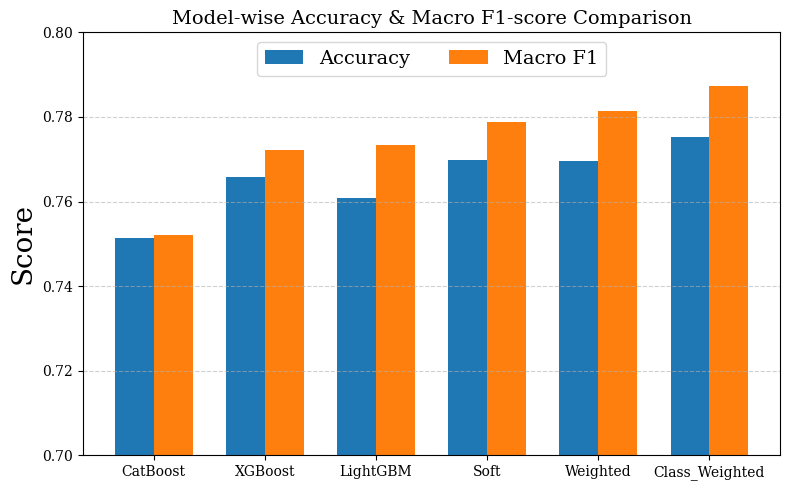

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 예시: 기존 결과 및 앙상블 결과 저장
metrics_summary = {
    'CatBoost':   {'accuracy': 0.751314, 'macro_f1': 0.752196},
    'XGBoost':    {'accuracy': 0.765804, 'macro_f1': 0.772247},
    'LightGBM':   {'accuracy': 0.760767, 'macro_f1': 0.773273},
    'Soft':   {'accuracy': ensemble_acc, 'macro_f1': ensemble_f1},  # <- 앙상블 결과 입력
    'Weighted': {'accuracy': weight_ensemble_acc, 'macro_f1': weight_ensemble_f1},
    'Class_Weighted': {'accuracy': final_ensemble_acc, 'macro_f1': final_ensemble_f1},
}

models = list(metrics_summary.keys())
accuracy = [metrics_summary[m]['accuracy'] for m in models]
macro_f1 = [metrics_summary[m]['macro_f1'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
rects2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1')

ax.set_ylabel('Score')
ax.set_title('Model-wise Accuracy & Macro F1-score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper center', ncol=2, fontsize=14)
ax.set_ylim(0.7, 0.8)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


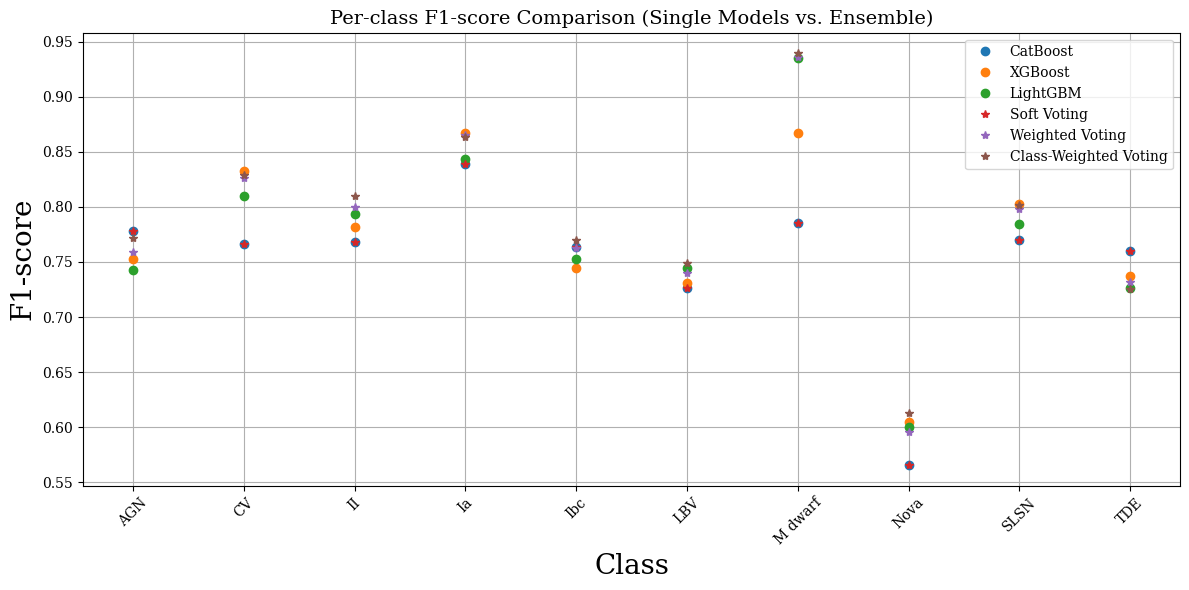

In [41]:
plt.figure(figsize=(12, 6))

# 기존 모델별 F1-score (예시로 per_class_df를 그대로 활용)
for model_name in ['CatBoost', 'XGBoost', 'LightGBM']:
    plt.plot(class_names, per_class_df[(model_name, 'f1-score')], marker='o', label=model_name, ls='')

# 앙상블(soft voting) F1-score 추가
from sklearn.metrics import f1_score
ensemble_f1_class = f1_score(y_test_encoded, ensemble_pred, average=None)  # array, 클래스 순서는 class_names와 같음
plt.plot(class_names, ensemble_f1_class, marker='*', label='Soft Voting', linewidth=3, ls='')

# Weight
weight_ensemble_f1_class = f1_score(y_test_encoded, weight_ensemble_pred, average=None)  # array, 클래스 순서는 class_names와 같음
plt.plot(class_names, weight_ensemble_f1_class, marker='*', label='Weighted Voting', linewidth=3, ls='')

#
class_weight_ensemble_f1_class = f1_score(y_test_encoded, final_ensemble_pred, average=None)  # array, 클래스 순서는 class_names와 같음
plt.plot(class_names, class_weight_ensemble_f1_class, marker='*', label='Class-Weighted Voting', linewidth=3, ls='')

plt.title('Per-class F1-score Comparison (Single Models vs. Ensemble)')
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()


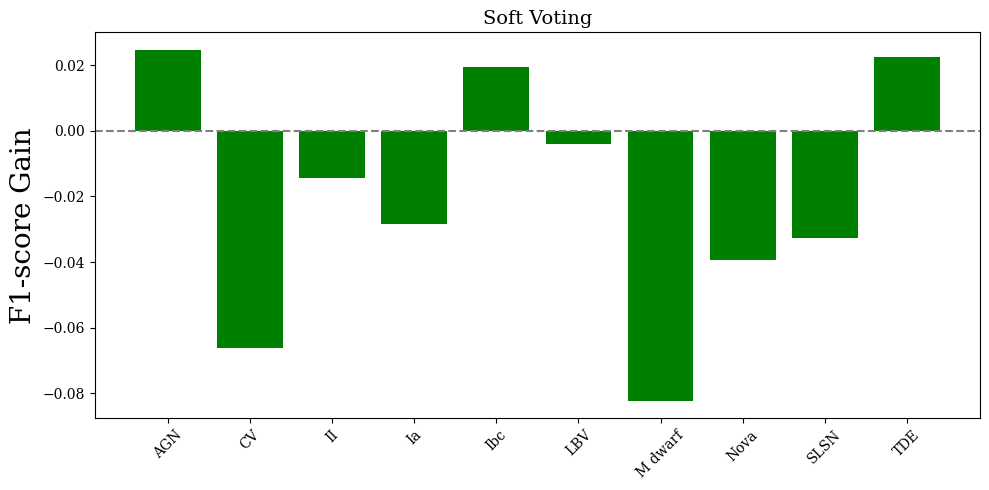

In [30]:
improvement = np.array(ensemble_f1_class) - np.array([per_class_df[(model_name, 'f1-score')] for model_name in ['XGBoost']])[0]
plt.figure(figsize=(10, 5))
plt.bar(class_names, improvement, color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('F1-score Gain')
plt.title('Soft Voting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


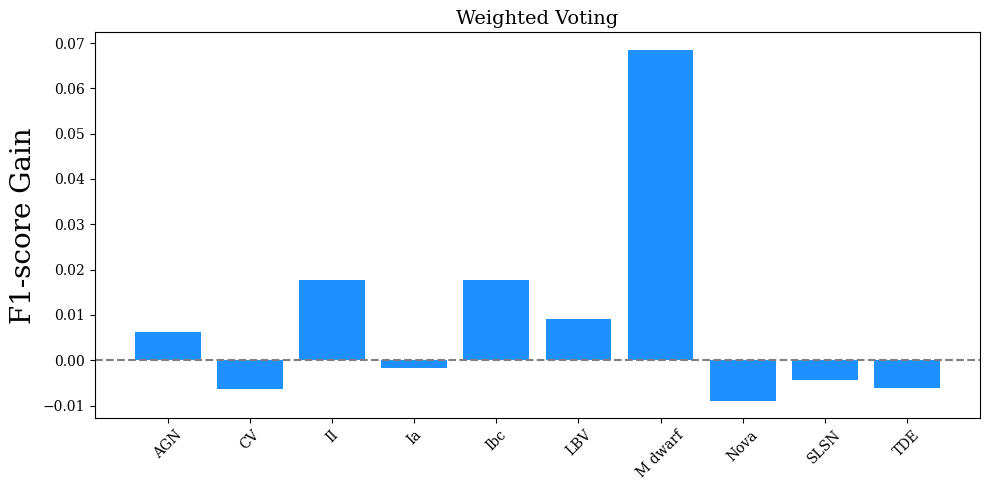

In [31]:
weight_improvement = np.array(weight_ensemble_f1_class) - np.array([per_class_df[(model_name, 'f1-score')] for model_name in ['XGBoost']])[0]
plt.figure(figsize=(10, 5))
plt.bar(class_names, weight_improvement, color='dodgerblue')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('F1-score Gain')
plt.title('Weighted Voting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# CV

In [32]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt


In [33]:
# 데이터셋 준비 (X, y, uid)
# X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
# y = data['Class']
# uids = data['uid']
# X.fillna(-99, inplace=True)

# label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# class_names = label_encoder.classes_

groups = uids.values
gkf = GroupKFold(n_splits=5)

In [34]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupKFold

lgbm_macro_f1s, catb_macro_f1s, xgb_macro_f1s = [], [], []
soft_macro_f1s, weight_macro_f1s = [], []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=groups)):
    print(f"=== Fold {fold+1} ===")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # LightGBM
    lgbm_params['force_row_wise'] = True
    lgbm_model = LGBMClassifier(**lgbm_params, n_jobs=n_jobs)
    lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='multi_logloss', callbacks=[lgb.early_stopping(stopping_rounds=30)])
    lgbm_pred = lgbm_model.predict(X_val)
    lgbm_prob = lgbm_model.predict_proba(X_val)
    lgbm_macro_f1s.append(f1_score(y_val, lgbm_pred, average='macro'))

    # CatBoost
    cat_model = CatBoostClassifier(**cat_params, verbose=0)
    train_pool = Pool(X_train, label=y_train)
    eval_pool = Pool(X_val, label=y_val)
    cat_model.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=30)
    cat_pred = cat_model.predict(X_val)
    cat_prob = cat_model.predict_proba(X_val)
    catb_macro_f1s.append(f1_score(y_val, cat_pred, average='macro'))

    # XGBoost (안전설정)
    local_xgb_params = xgb_params.copy()
    for key in ['use_label_encoder', 'n_jobs', 'eval_metric']:
        local_xgb_params.pop(key, None)
    xgb_model = XGBClassifier(
        **local_xgb_params,
        n_jobs=15,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0,
        num_class=len(class_names)
    )
    # xgb_model.fit(X_train, y_train, early_stopping_rounds=30, eval_set=[(X_val, y_val)], verbose=False)
    xgb_model.fit(X_train, y_train, verbose=False)
    xgb_pred = xgb_model.predict(X_val)
    xgb_prob = xgb_model.predict_proba(X_val)
    xgb_macro_f1s.append(f1_score(y_val, xgb_pred, average='macro'))

    # 소프트 보팅
    soft_prob = (lgbm_prob + cat_prob + xgb_prob) / 3
    soft_pred = np.argmax(soft_prob, axis=1)
    soft_macro_f1s.append(f1_score(y_val, soft_pred, average='macro'))

    # 웨이트 보팅 (best_weights 필요)
    weight_prob = (lgbm_prob * best_weights[0]) + (cat_prob * best_weights[1]) + (xgb_prob * best_weights[2])
    weight_pred = np.argmax(weight_prob, axis=1)
    weight_macro_f1s.append(f1_score(y_val, weight_pred, average='macro'))

# 결과 DataFrame 및 저장
# results_df = pd.DataFrame({
#     'LightGBM': lgbm_macro_f1s,
#     'CatBoost': catb_macro_f1s,
#     'XGBoost': xgb_macro_f1s,
#     'Soft Voting': soft_macro_f1s,
#     'Weighted Voting': weight_macro_f1s
# })
# results_df.to_csv(cv_result_path, index=False)

=== Fold 1 ===
[LightGBM] [Info] Total Bins 198900
[LightGBM] [Info] Number of data points in the train set: 226202, number of used features: 780
[LightGBM] [Info] Start training from score -2.270960
[LightGBM] [Info] Start training from score -2.279563
[LightGBM] [Info] Start training from score -2.184791
[LightGBM] [Info] Start training from score -2.206681
[LightGBM] [Info] Start training from score -2.291865
[LightGBM] [Info] Start training from score -2.224267
[LightGBM] [Info] Start training from score -2.558713
[LightGBM] [Info] Start training from score -2.323907
[LightGBM] [Info] Start training from score -2.405943
[LightGBM] [Info] Start training from score -2.331068
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

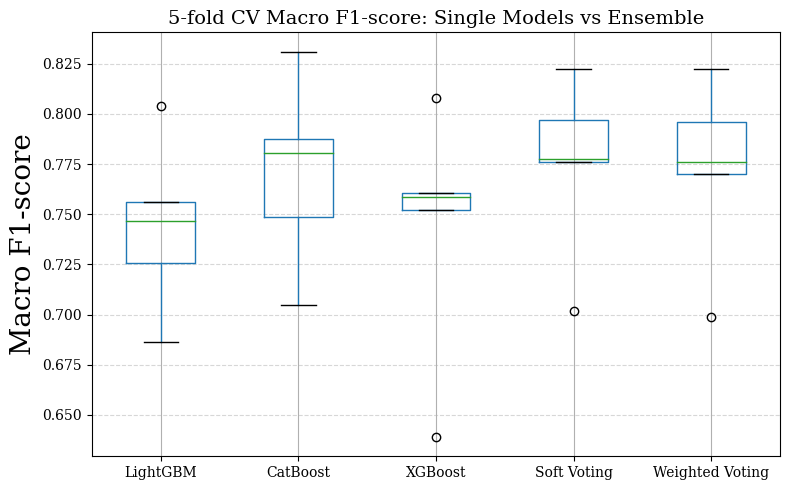

In [37]:
results_df = pd.DataFrame({
    'LightGBM': lgbm_macro_f1s,
    'CatBoost': catb_macro_f1s,
    'XGBoost': xgb_macro_f1s,
    'Soft Voting': soft_macro_f1s,
    'Weighted Voting': weight_macro_f1s
})

cv_result_path = os.path.join(path_save, 'macro_f1_cv_results.csv')

results_df.to_csv(cv_result_path, index=False)

plt.figure(figsize=(8,5))
results_df.boxplot()
plt.ylabel('Macro F1-score')
plt.title('5-fold CV Macro F1-score: Single Models vs Ensemble')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Feature Importance

In [61]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 환경변수로 core 제한 (추가 안정성 확보)
os.environ["OMP_NUM_THREADS"] = "15"
os.environ["MKL_NUM_THREADS"] = "15"
os.environ["TBB_NUM_THREADS"] = "15"

# 데이터 샘플링
X_sample = X_train.sample(n=1000, random_state=42)

# SHAP explainer 계산 (TreeExplainer는 model structure 사용)
explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_sample)
importance_cat = np.abs(shap_values_cat).mean(axis=0)

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_sample)
importance_xgb = np.abs(shap_values_xgb).mean(axis=0)

explainer_lgb = shap.TreeExplainer(lgbm_model)
shap_values_lgb = explainer_lgb.shap_values(X_sample)
importance_lgb = np.abs(shap_values_lgb).mean(axis=0)


In [72]:
mean_importance_cat = importance_cat.sum(axis=0)
mean_importance_xgb = importance_xgb.sum(axis=0)
mean_importance_lgb = importance_lgb.sum(axis=0)

In [90]:
# Normalize
nor_mean_importance_xgb = mean_importance_xgb / mean_importance_xgb.sum()
nor_mean_importance_cat = mean_importance_cat / mean_importance_cat.sum()
nor_mean_importance_lgb = mean_importance_lgb / mean_importance_lgb.sum()

# Voting 방식
importance_soft = (nor_mean_importance_cat + nor_mean_importance_xgb + nor_mean_importance_lgb) / 3
nor_importance_soft = importance_soft / importance_soft.sum()
w_cat, w_xgb, w_lgb = best_weights
importance_weighted = (
    nor_mean_importance_cat * w_cat +
    nor_mean_importance_xgb * w_xgb +
    nor_mean_importance_lgb * w_lgb
)

nor_importance_weighted = importance_weighted / importance_weighted.sum()

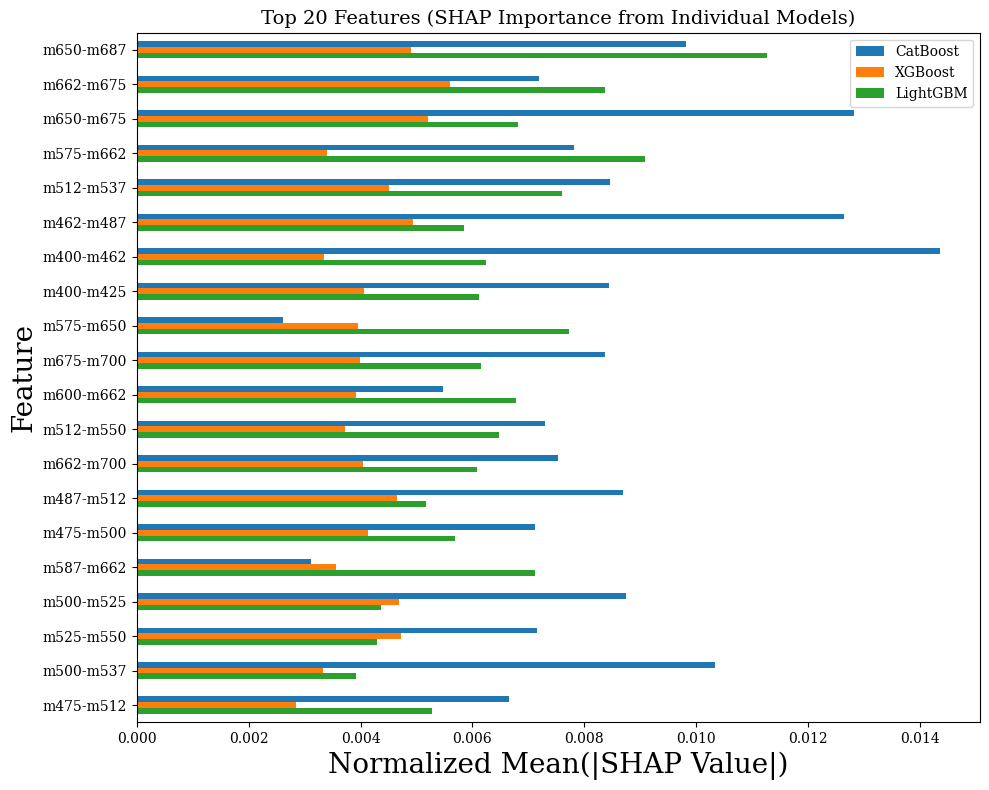

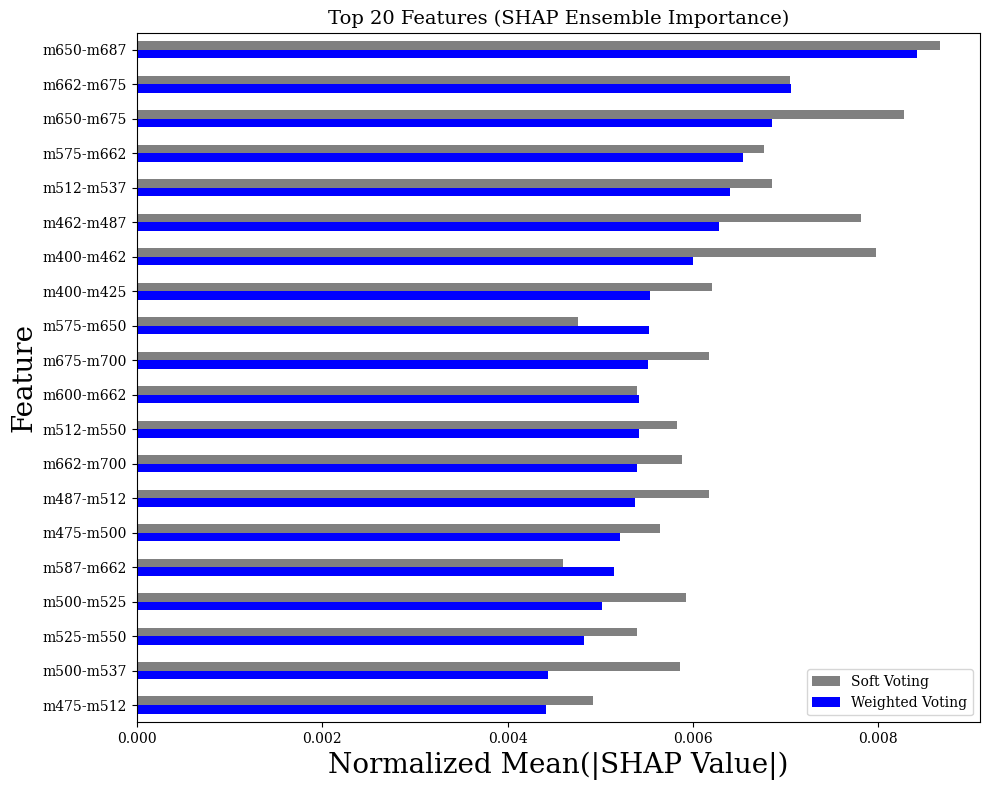

In [91]:

# DataFrame
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'CatBoost': nor_mean_importance_cat,
    'XGBoost': nor_mean_importance_xgb,
    'LightGBM': nor_mean_importance_lgb,
    'Soft Voting': nor_importance_soft,
    'Weighted Voting': nor_importance_weighted
}).set_index('Feature')

# 상위 20개 시각화
importance_df_sorted = importance_df.sort_values(by='Weighted Voting', ascending=False).head(20)

importance_df_sorted[['CatBoost', 'XGBoost', 'LightGBM']].plot.barh(stacked=False, figsize=(10, 8))
plt.gca().invert_yaxis()
plt.title("Top 20 Features (SHAP Importance from Individual Models)")
plt.xlabel("Normalized Mean(|SHAP Value|)")
plt.tight_layout()
plt.show()

importance_df_sorted[['Soft Voting', 'Weighted Voting']].plot.barh(stacked=False, figsize=(10, 8), color=['gray', 'blue'])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (SHAP Ensemble Importance)")
plt.xlabel("Normalized Mean(|SHAP Value|)")
plt.tight_layout()
plt.show()

In [94]:
feature_score_table = Table()
feature_score_table['feature'] = feature_names
for filte in MEDIUM_BANDS:
    feature_score_table[filte] = 0.

In [106]:
default_score = 1.0

weight_vote_score_table = feature_score_table.copy()
for ff, feature in enumerate(weight_vote_score_table['feature']):

    weight = nor_importance_weighted[ff]

    filter0 = feature.split('-')[0]
    filter1 = feature.split('-')[1]

    weight_vote_score_table[filter0][ff] = default_score * weight
    weight_vote_score_table[filter1][ff] = default_score * weight

weight_vote_score_table[:3]

feature,m400,m412,m425,m437,m450,m462,m475,m487,m500,m512,m525,m537,m550,m562,m575,m587,m600,m612,m625,m637,m650,m662,m675,m687,m700,m712,m725,m737,m750,m762,m775,m787,m800,m812,m825,m837,m850,m862,m875,m887
object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
m400-m412,0.0032563461435849116,0.0032563461435849116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
m400-m425,0.005534739742790299,0.0,0.005534739742790299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
m400-m437,0.003168104168292319,0.0,0.0,0.003168104168292319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


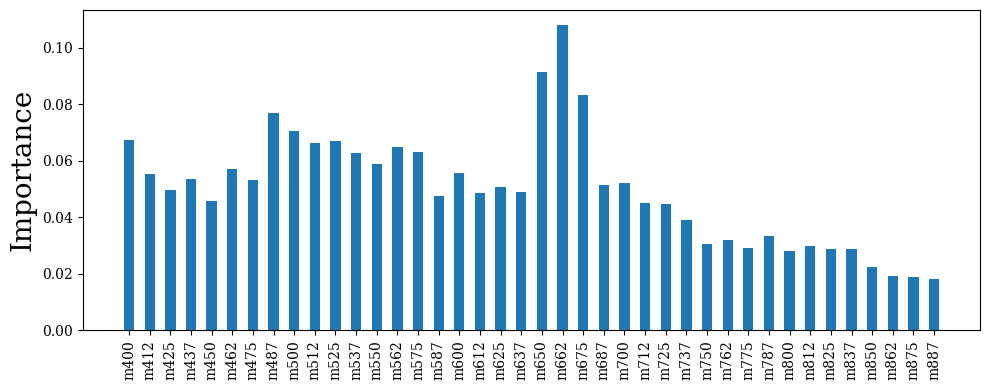

In [110]:
total_filter_scores = [weight_vote_score_table[filte].sum() for filte in MEDIUM_BANDS]
colors = makeSpecColors(len(MEDIUM_BANDS), palette='Spectral')
plt.figure(figsize=(10, 4))
plt.bar(MEDIUM_BANDS, total_filter_scores, width=0.5,)
_ = plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.tight_layout()

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

def compute_filter_scores_from_feature_importance(
    feature_names,
    importance,
    medium_band_filters,
    default_score=1.0,
    normalize=True,
    plot=True,
    title="Filter-wise Importance from Feature Scores"
):
    """
    Args:
        feature_names: list of color feature names (e.g., 'm400-m425')
        importance: 1D array or list of feature importance values (length = len(feature_names))
        medium_band_filters: list of medium-band filters to accumulate importance (e.g., ['m400', 'm425', ...])
        default_score: multiplier for each feature's normalized importance (default=1.0)
        normalize: whether to normalize input importance to sum to 1
        plot: whether to show bar chart of total filter-wise importance
        title: plot title
    Returns:
        score_table: Table of importance contribution from each feature to each filter
        total_filter_scores: 1D list of total importance per filter
    """
    if normalize:
        importance = np.array(importance)
        importance = importance / importance.sum()

    # Initialize feature score table
    score_table = Table()
    score_table['feature'] = feature_names
    for filt in medium_band_filters:
        score_table[filt] = 0.0

    # Fill values
    for ff, feat in enumerate(score_table['feature']):
        filt0, filt1 = feat.split('-')
        if filt0 in medium_band_filters:
            score_table[filt0][ff] = default_score * importance[ff]
        if filt1 in medium_band_filters:
            score_table[filt1][ff] = default_score * importance[ff]

    # Total score per filter
    total_scores = [score_table[filt].sum() for filt in medium_band_filters]

    # Plot
    if plot:
        colors = makeSpecColors(len(medium_band_filters), palette='Spectral')
        plt.figure(figsize=(10, 4))
        plt.bar(medium_band_filters, total_scores, width=0.5, color=colors, edgecolor='black')
        plt.xticks(rotation=90)
        plt.ylabel("Importance")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return score_table, total_scores

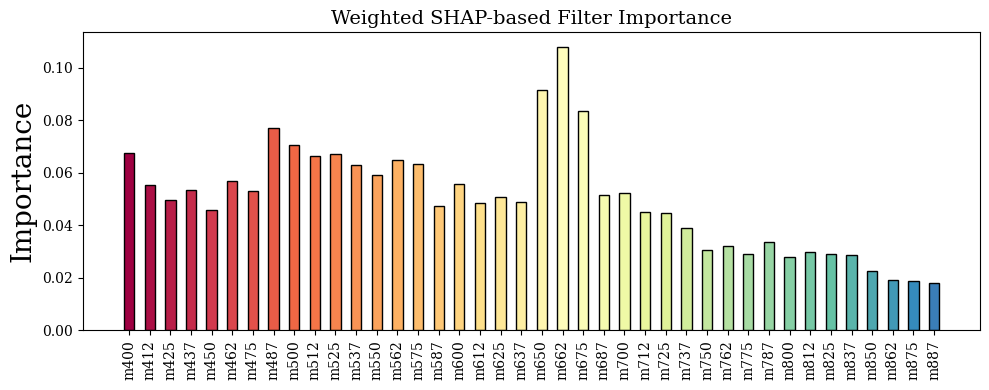

In [114]:
score_table, total_scores = compute_filter_scores_from_feature_importance(
    feature_names=X_train.columns,
    importance=nor_importance_weighted,
    medium_band_filters=MEDIUM_BANDS,
    default_score=1.0,
    normalize=True,
    plot=True,
    title="Weighted SHAP-based Filter Importance"
)

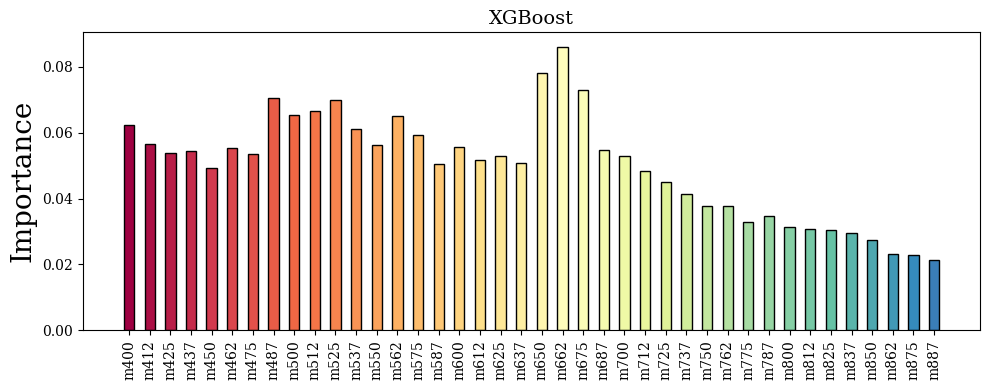

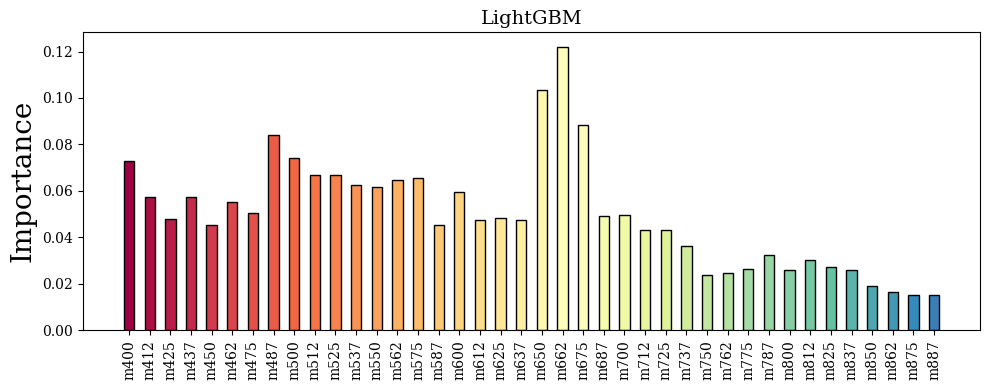

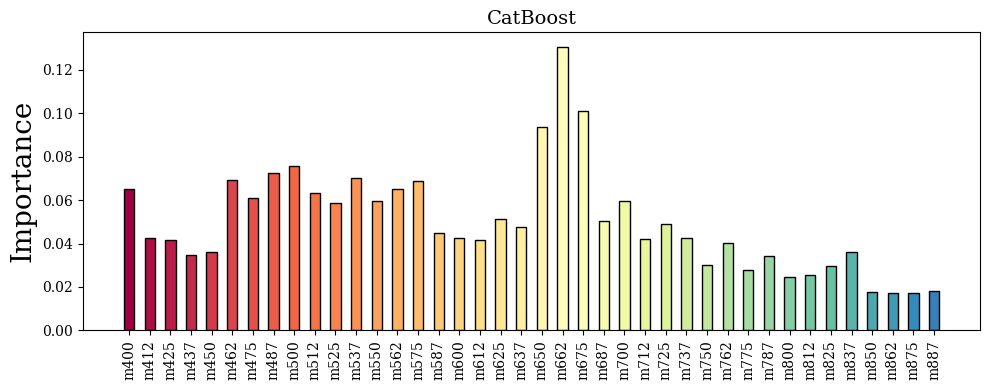

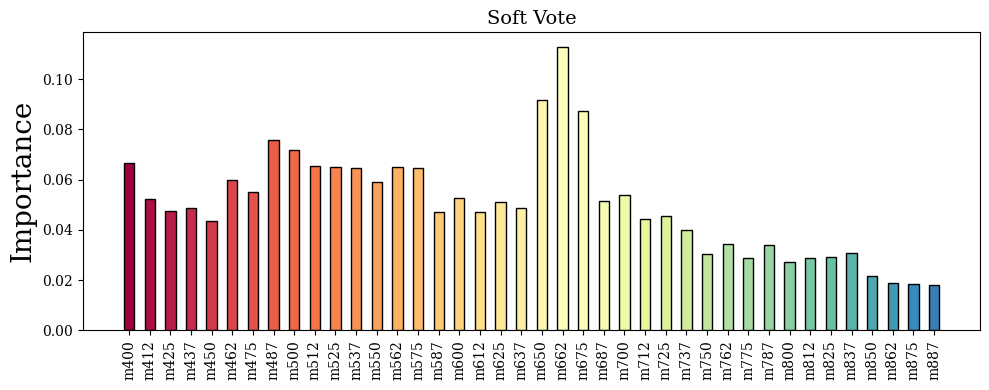

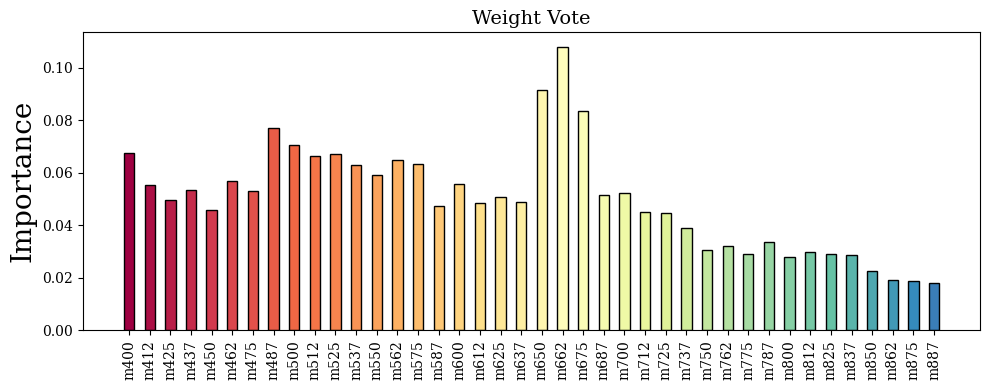

In [116]:
for title, importance in zip(["XGBoost", "LightGBM", "CatBoost", 'Soft Vote', 'Weight Vote'],
                             [nor_mean_importance_xgb, nor_mean_importance_lgb, nor_mean_importance_cat, nor_importance_soft, nor_importance_weighted]):

    score_table, total_scores = compute_filter_scores_from_feature_importance(
        feature_names=X_train.columns,
        importance=importance,
        medium_band_filters=MEDIUM_BANDS,
        default_score=1.0,
        normalize=True,
        plot=True,
        title=title,
    )

# Result Save

In [119]:
path_final_models = os.path.join(MODEL, "final_normal_class_model")
os.makedirs(path_final_models, exist_ok=True)

In [120]:
# CatBoost
cat_model.save_model(os.path.join(path_final_models, "catboost_model.cbm"))

# XGBoost
xgb_model.save_model(os.path.join(path_final_models, "xgboost_model.json"))  # or .bst

# LightGBM
import joblib
joblib.dump(lgbm_model, os.path.join(path_final_models, "lightgbm_model.pkl"))

['/home/gpaek/SED-Classifier/notebook/../model/final_normal_class_model/lightgbm_model.pkl']

In [121]:
import numpy as np
import joblib
import shap
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 불러오기
def load_ensemble_models(cat_path, xgb_path, lgb_path):
    cat = CatBoostClassifier()
    cat.load_model(cat_path)

    xgb = XGBClassifier()
    xgb.load_model(xgb_path)

    lgb = joblib.load(lgb_path)

    return cat, xgb, lgb

# 예측 함수 정의
def ensemble_predict(X, cat, xgb, lgb, weights=None):
    """
    Args:
        X: input features (DataFrame or ndarray)
        cat, xgb, lgb: trained model instances
        weights: None for soft voting, or list like [w_cat, w_xgb, w_lgb]
    Returns:
        pred_class: final predicted class index
        pred_probs: averaged or weighted probability
    """
    p_cat = cat.predict_proba(X)
    p_xgb = xgb.predict_proba(X)
    p_lgb = lgb.predict_proba(X)

    if weights is None:
        # soft voting
        probs = (p_cat + p_xgb + p_lgb) / 3
    else:
        probs = (
            p_cat * weights[0] +
            p_xgb * weights[1] +
            p_lgb * weights[2]
        )

    pred_class = np.argmax(probs, axis=1)
    return pred_class, probs

In [126]:
# Load models
cat, xgb, lgb = load_ensemble_models(
    os.path.join(path_final_models, "catboost_model.cbm"),
    os.path.join(path_final_models, "xgboost_model.json"),
    os.path.join(path_final_models, "lightgbm_model.pkl"),
)

# Predict
y_pred, y_probs = ensemble_predict(X_test, cat, xgb, lgb, weights=best_weights)

In [125]:
import json
json.dump({"weights": [val for val in best_weights]}, open(os.path.join(path_final_models, "ensemble_weights.json"), "w"))